# Iris Flower Classification

## CodeAlpha Data Science Internship - Task 1

### Objective
The objective of this project is to build a machine learning model that can classify Iris flowers into three species: Setosa, Versicolor, and Virginica, based on their sepal and petal measurements.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df["species"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Exploring the Dataset

Before building the machine learning model, we will explore the dataset to understand its structure and contents.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

## Data Preparation

The target values are converted from numerical labels into their corresponding species names to make the dataset easier to understand and visualize.

In [8]:
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [9]:
df["species"].value_counts()

species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64

## Data Visualization

Visualizing the data helps us understand the relationships between flower measurements and identify patterns among the three Iris species.

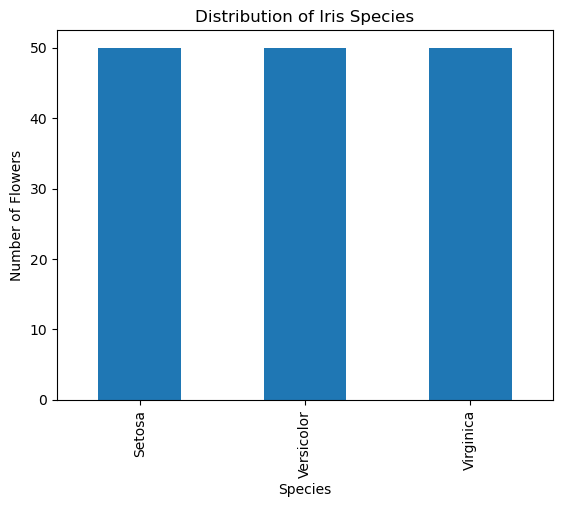

In [10]:
df["species"].value_counts().plot(kind="bar")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Flowers")
plt.show()

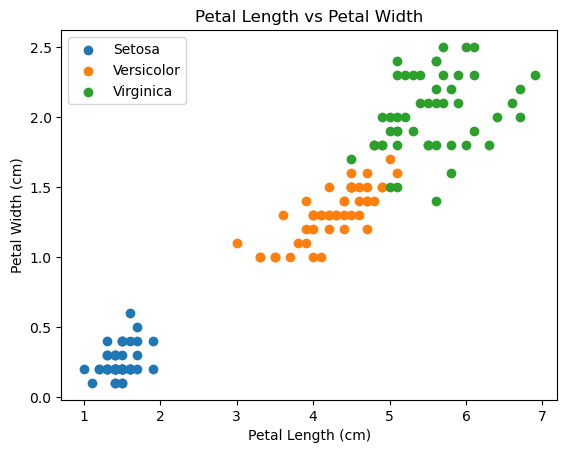

In [11]:
for species in df["species"].unique():
    subset = df[df["species"] == species]
    
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species
    )

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.show()

## Preparing the Data for Machine Learning

The dataset is divided into input features (X) and the target variable (y). The data is then split into training and testing sets so that the model can be trained on one portion and evaluated on unseen data.

In [12]:
X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


## Model Training

A Random Forest Classifier is used to train the model. Random Forest combines multiple decision trees to make accurate and reliable predictions.

In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


## Model Evaluation

The trained model is tested using unseen data. Its performance is evaluated using accuracy, a classification report, and a confusion matrix.

In [14]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9


In [15]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.82      0.90      0.86        10
   Virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


## Confusion Matrix Visualization

The confusion matrix provides a visual representation of the model's predictions and helps identify which flower species were classified correctly or incorrectly.

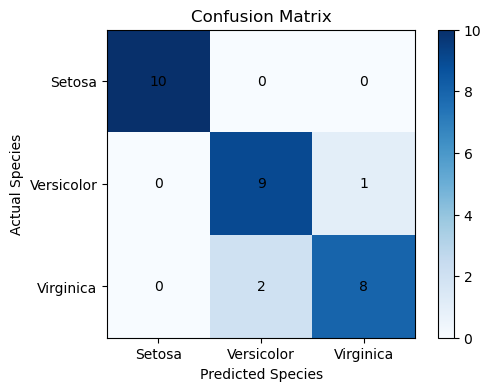

In [17]:
plt.figure(figsize=(6, 4))

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

species_names = ["Setosa", "Versicolor", "Virginica"]

plt.xticks(range(3), species_names)
plt.yticks(range(3), species_names)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

## Predicting a New Iris Flower

The trained model can be used to predict the species of a new Iris flower based on its sepal and petal measurements.

In [18]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=X.columns
)

prediction = model.predict(new_flower)

print("Predicted Species:", prediction[0])

Predicted Species: Setosa


## Conclusion

In this project, a Random Forest Classifier was successfully developed to classify Iris flowers into Setosa, Versicolor, and Virginica based on their sepal and petal measurements.

The model achieved an accuracy of 90% on the test dataset, correctly classifying 27 out of 30 flowers. Setosa was classified perfectly, while a small number of misclassifications occurred between Versicolor and Virginica due to similarities in their measurements.

Overall, the project demonstrates how machine learning classification can be used to identify flower species based on measurable features.